# France at the 2026 World Cup

Can France actually win this World Cup? After a dominant group stage and a
comfortable run through the knockouts so far, I wanted to see what the
numbers say, so I collected their match stats and simulated the rest of
the tournament.

Zhanet Georgieva, Data Science student;

Update - Quarter-final complete: France beat Morocco 2-0. 6 matches played, 6 wins.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# transparent, dark-theme-friendly charts
plt.rcParams.update({
    "figure.facecolor": "none", "axes.facecolor": "none",
    "savefig.facecolor": "none", "text.color": "#888888",
    "axes.labelcolor": "#888888", "xtick.color": "#888888",
    "ytick.color": "#888888", "axes.edgecolor": "#555555",
})

## The data

Two tables: the results and the detailed stats for each game. I entered
everything by hand from the official match reports, since there is no free
API for World Cup data.


In [2]:
# Match results
matches = pd.DataFrame({
    "match": ["France vs Senegal", "France vs Iraq", "Norway vs France",
              "France vs Sweden", "France vs Paraguay", "France vs Morocco"],
    "date": ["June 16", "June 22", "June 26", "June 30", "July 5", "July 10"],
    "goals_france": [3, 3, 4, 3, 1, 2],
    "goals_opponent": [1, 0, 1, 0, 0, 0],
    "result": ["Win", "Win", "Win", "Win", "Win", "Win"],
})
matches


,match,date,goals_france,goals_opponent,result
0,France vs Senegal,June 16,3,1,Win
1,France vs Iraq,June 22,3,0,Win
2,Norway vs France,June 26,4,1,Win
3,France vs Sweden,June 30,3,0,Win
4,France vs Paraguay,July 5,1,0,Win
5,France vs Morocco,July 10,2,0,Win


In [3]:
# Detailed match statistics
stats = pd.DataFrame({
    "match": ["vs Senegal", "vs Iraq", "vs Norway", "vs Sweden", "vs Paraguay", "vs Morocco"],
    "goals": [3, 3, 4, 3, 1, 2],
    "conceded": [1, 0, 1, 0, 0, 0],
    "xg": [1.79, 2.67, 1.50, 3.24, 1.45, 3.69],
    "xg_conceded": [0.53, 0.63, 1.70, 0.70, 0.13, 0.14],
    "shots": [11, 19, 18, 25, 15, 22],
    "shots_on_target": [8, 5, 9, 12, 5, 8],
    "possession": [53, 56, 57, 61, 76, 48],
    "passes": [505, 540, 480, 604, 753, 476],
    "passes_completed": [444, 486, 413, 532, 678, 464],
    "pass_accuracy": [88, 90, 86, 88, 90, 89],
    "yellow_cards": [0, 0, 1, 1, 1, 1],
    "corners": [6, 4, 5, 9, 12, 5],
    "saves": [1, 0, 3, 3, 1, 1],  # Maignan
})
stats


,match,goals,conceded,xg,xg_conceded,shots,shots_on_target,possession,passes,passes_completed,pass_accuracy,yellow_cards,corners,saves
0,vs Senegal,3,1,1.79,0.53,11,8,53,505,444,88,0,6,1
1,vs Iraq,3,0,2.67,0.63,19,5,56,540,486,90,0,4,0
2,vs Norway,4,1,1.50,1.70,18,9,57,480,413,86,1,5,3
3,vs Sweden,3,0,3.24,0.70,25,12,61,604,532,88,1,9,3
4,vs Paraguay,1,0,1.45,0.13,15,5,76,753,678,90,1,12,1
5,vs Morocco,2,0,3.69,0.14,22,8,48,476,464,89,1,5,1


## Simulating the knockout stage

The idea: goals in a football match roughly follow a Poisson distribution.
France have averaged 2.39 xG scored and 0.64 xG conceded per game across all
6 matches so far. For a head-to-head matchup I use a blended Poisson model:
each team's scoring rate is the average of its own attack rate and the
opponent's defensive weakness. A draw goes to penalties, treated as a coin
flip. Then I simulate the remaining rounds 10,000 times.

All 4 semifinalists are now confirmed: **France vs Spain** and
**England vs Argentina**. Every rate used below - for all four teams, both
attack and defense - comes from exact match-by-match xG (48 data points
total). No tournament-level estimates remain anywhere in the model.


In [4]:
import random

def simulate_h2h(lam_a, lam_b, n_simulations=10_000, seed=42):
    """Head-to-head Poisson model: each team\'s scoring rate is the average
    of its own attack rate and the opponent\'s defensive weakness."""
    rng = np.random.default_rng(seed)
    r = random.Random(seed)
    wins = 0
    for _ in range(n_simulations):
        a = rng.poisson(lam_a)
        b = rng.poisson(lam_b)
        if a > b:
            wins += 1
        elif a == b:
            wins += 1 if r.random() > 0.5 else 0
    return wins / n_simulations

# ---- France: exact match-by-match xG, both ends ----
avg_goals_scored = stats["xg"].mean()             # 2.39
avg_goals_conceded = stats["xg_conceded"].mean()  # 0.64

# ---- Spain: exact match-by-match xG, both ends ----
spain_xg_by_match = [1.96, 1.69, 2.80, 0.86, 2.30, 2.10]  # Belgium, Portugal, Austria, Uruguay, Saudi Arabia, Cape Verde
spain_xga_by_match = [0.34, 0.63, 0.32, 0.20, 0.14, 0.20]  # same order
spain_avg_scored = sum(spain_xg_by_match) / len(spain_xg_by_match)      # 1.95
spain_avg_conceded = sum(spain_xga_by_match) / len(spain_xga_by_match)  # 0.31

# ---- England: exact match-by-match xG, both ends ----
england_xg_by_match = [1.04, 1.61, 2.16, 1.56, 1.36, 3.20]  # Norway, Mexico, DR Congo, Panama, Ghana, Croatia
england_xga_by_match = [0.67, 1.88, 0.77, 0.66, 0.17, 0.70]  # same order
england_avg_scored = sum(england_xg_by_match) / len(england_xg_by_match)      # 1.82
england_avg_conceded = sum(england_xga_by_match) / len(england_xga_by_match)  # 0.81

# ---- Argentina: exact match-by-match xG, both ends ----
argentina_xg_by_match = [1.94, 2.84, 2.26, 2.13, 2.36, 1.26]  # Switzerland, Egypt, Cape Verde, Jordan, Austria, Algeria
argentina_xga_by_match = [0.47, 0.89, 0.47, 0.76, 0.53, 0.32]  # same order
argentina_avg_scored = sum(argentina_xg_by_match) / len(argentina_xg_by_match)      # 2.13
argentina_avg_conceded = sum(argentina_xga_by_match) / len(argentina_xga_by_match)  # 0.57

# ---- Semi Final 1: France vs Spain ----
lam_fr_sf1 = (avg_goals_scored + spain_avg_conceded) / 2
lam_sp_sf1 = (spain_avg_scored + avg_goals_conceded) / 2
p_france_wins_sf1 = simulate_h2h(lam_fr_sf1, lam_sp_sf1)
print(f"Semi Final 1 - France vs Spain: France {p_france_wins_sf1:.1%}")

# ---- Semi Final 2: England vs Argentina ----
lam_eng_sf2 = (england_avg_scored + argentina_avg_conceded) / 2
lam_arg_sf2 = (argentina_avg_scored + england_avg_conceded) / 2
p_england_wins_sf2 = simulate_h2h(lam_eng_sf2, lam_arg_sf2)
p_argentina_wins_sf2 = 1 - p_england_wins_sf2
print(f"Semi Final 2 - England vs Argentina: England {p_england_wins_sf2:.1%}, Argentina {p_argentina_wins_sf2:.1%}")

# ---- Final: France vs whoever wins SF2 ----
lam_fr_vs_eng = (avg_goals_scored + england_avg_conceded) / 2
lam_eng_vs_fr = (england_avg_scored + avg_goals_conceded) / 2
p_france_beats_england = simulate_h2h(lam_fr_vs_eng, lam_eng_vs_fr)

lam_fr_vs_arg = (avg_goals_scored + argentina_avg_conceded) / 2
lam_arg_vs_fr = (argentina_avg_scored + avg_goals_conceded) / 2
p_france_beats_argentina = simulate_h2h(lam_fr_vs_arg, lam_arg_vs_fr)

weighted_final_win = (p_england_wins_sf2 * p_france_beats_england +
                       p_argentina_wins_sf2 * p_france_beats_argentina)
print(f"\nFrance win probability in the Final (weighted): {weighted_final_win:.1%}")

champion_prob = p_france_wins_sf1 * weighted_final_win
print(f"France - Champion probability: {champion_prob:.1%}")

# ---- Full bracket: every team\'s Champion probability ----
lam_sp_vs_eng = (spain_avg_scored + england_avg_conceded) / 2
lam_eng_vs_sp = (england_avg_scored + spain_avg_conceded) / 2
p_spain_beats_england = simulate_h2h(lam_sp_vs_eng, lam_eng_vs_sp)

lam_sp_vs_arg = (spain_avg_scored + argentina_avg_conceded) / 2
lam_arg_vs_sp = (argentina_avg_scored + spain_avg_conceded) / 2
p_spain_beats_argentina = simulate_h2h(lam_sp_vs_arg, lam_arg_vs_sp)

spain_champion = (1 - p_france_wins_sf1) * (p_england_wins_sf2 * p_spain_beats_england +
                                             p_argentina_wins_sf2 * p_spain_beats_argentina)
england_champion = p_england_wins_sf2 * (p_france_wins_sf1 * (1 - p_france_beats_england) +
                                          (1 - p_france_wins_sf1) * (1 - p_spain_beats_england))
argentina_champion = p_argentina_wins_sf2 * (p_france_wins_sf1 * (1 - p_france_beats_argentina) +
                                              (1 - p_france_wins_sf1) * (1 - p_spain_beats_argentina))

print("\nFull bracket - Champion probability by team (every rate above is exact match-by-match xG,")
print("no tournament-level estimates remain):")
print(f"France:      {champion_prob:.1%}")
print(f"Argentina:   {argentina_champion:.1%}")
print(f"Spain:       {spain_champion:.1%}")
print(f"England:     {england_champion:.1%}")
print(f"Sum check:   {champion_prob+spain_champion+argentina_champion+england_champion:.1%}")


Semi Final 1 - France vs Spain: France 51.8%
Semi Final 2 - England vs Argentina: England 44.3%, Argentina 55.7%

France win probability in the Final (weighted): 54.9%
France - Champion probability: 28.4%

Full bracket - Champion probability by team (every rate above is exact match-by-match xG,
no tournament-level estimates remain):
France:      28.4%
Argentina:   26.9%
Spain:       26.1%
England:     18.6%
Sum check:   100.0%


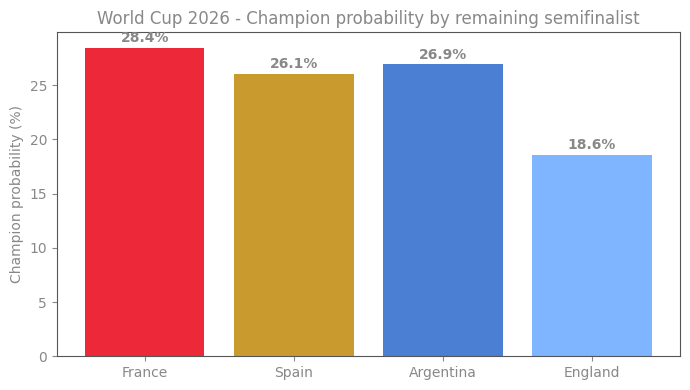

In [5]:
teams = ["France", "Spain", "Argentina", "England"]
probs = [champion_prob*100, spain_champion*100, argentina_champion*100, england_champion*100]
colors = ["#ED2939", "#c99a2e", "#4a7fd4", "#7fb4ff"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(teams, probs, color=colors)
ax.set_ylabel("Champion probability (%)")
ax.set_title("World Cup 2026 - Champion probability by remaining semifinalist")
for bar, p in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{p:.1f}%", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()


## Dashboard

I also made an HTML dashboard with the main numbers. It gets saved to
`dashboard.html`, so you can open it in a browser too.


In [6]:
from IPython.display import HTML

# ===== HEATMAP DATA (computed in Python, no JS needed) =====
def lerp(a, b, t):
    return a + (b - a) * t

def heat_color(t):
    r = round(lerp(10, 74, t))
    g = round(lerp(32, 159, t))
    b = round(lerp(80, 255, t))
    return f"rgb({r},{g},{b})"

heatmap_metrics = [
    {"label": "Goals",           "vals": stats["goals"].tolist()},
    {"label": "Shots",           "vals": stats["shots"].tolist()},
    {"label": "On Target",       "vals": stats["shots_on_target"].tolist()},
    {"label": "Possession %",    "vals": stats["possession"].tolist()},
    {"label": "Pass Acc %",      "vals": stats["pass_accuracy"].tolist()},
    {"label": "Corners",         "vals": stats["corners"].tolist()},
    {"label": "Saves (Maignan)", "vals": stats["saves"].tolist()},
]
heatmap_matches = ["vs " + m.split("vs ")[-1] if "vs" in m else m for m in stats["match"]]
heatmap_matches = list(stats["match"])  # already "vs X" formatted

heatmap_header = "<tr><th></th>" + "".join(f"<th>{m}</th>" for m in heatmap_matches) + "</tr>"
heatmap_rows = ""
for metric in heatmap_metrics:
    vals = metric["vals"]
    mn, mx = min(vals), max(vals)
    row = f'<tr><td class="hm-metric">{metric["label"]}</td>'
    for v in vals:
        t = 0 if mx == mn else (v - mn) / (mx - mn)
        bg = heat_color(t)
        fg = "#fff" if t >= 0.45 else "#4a9eff"
        row += f'<td class="hm-cell" style="background:{bg};color:{fg}">{v}</td>'
    row += "</tr>"
    heatmap_rows += row
heatmap_table_html = f'<table class="hm-table"><thead>{heatmap_header}</thead><tbody>{heatmap_rows}</tbody></table>'

# ===== xG vs GOALS BAR SECTION (computed in Python) =====
max_xg = stats["xg"].max()
max_goals = stats["goals"].max()
xg_blocks = ""
for i, row in stats.iterrows():
    w_xg = round(row["xg"] / max_xg * 97)
    w_goal = round(row["goals"] / max_goals * 100)
    xg_blocks += f'''
    <div class="match-block"><div class="match-label">{row["match"]}</div>
      <div class="bar-row"><div class="bar-type">xG Expected</div><div class="bar-track"><div class="bar-fill bar-xg" style="width:{w_xg}%">{row["xg"]:.2f}</div></div><div class="bar-val" style="color:#4a9eff">{row["xg"]:.2f}</div></div>
      <div class="bar-row"><div class="bar-type">Goals Scored</div><div class="bar-track"><div class="bar-fill bar-goal" style="width:{w_goal}%">{row["goals"]}</div></div><div class="bar-val" style="color:#ED2939">{row["goals"]}</div></div>
    </div>
    <hr class="xg-div">'''
xg_blocks = xg_blocks.rsplit('<hr class="xg-div">', 1)[0]  # drop trailing divider

# ===== TOURNAMENT SUMMARY NUMBERS =====
total_shots = int(stats["shots"].sum())
total_on_target = int(stats["shots_on_target"].sum())
total_passes = int(stats["passes"].sum())
total_passes_completed = int(stats["passes_completed"].sum())
avg_pass_acc = round(stats["pass_accuracy"].mean())
avg_possession = round(stats["possession"].mean(), 1)
total_corners = int(stats["corners"].sum())
total_yellow = int(stats["yellow_cards"].sum())
total_xg = round(stats["xg"].sum(), 2)
total_goals = int(stats["goals"].sum())
total_conceded = int(stats["conceded"].sum())
n_matches = len(stats)

# ===== FULL DASHBOARD HTML =====
html = f"""
<!DOCTYPE html>
<html>
<head>
<link href="https://fonts.googleapis.com/css2?family=Bebas+Neue&family=Inter:wght@300;400;600;700;800;900&display=swap" rel="stylesheet">
<style>
*{{margin:0;padding:0;box-sizing:border-box}}
body{{font-family:'Inter',sans-serif;background:transparent;padding:24px}}
.db{{font-family:'Inter',sans-serif;background:#071428;padding:20px;border-radius:16px;max-width:1200px;margin:0 auto}}
.hero{{border-radius:14px;padding:32px 36px;margin-bottom:18px;position:relative;overflow:hidden;display:grid;grid-template-columns:auto 1fr auto;align-items:center;gap:24px;background:#0a1e45;min-height:240px}}
.hero-stripe{{position:absolute;top:0;left:0;bottom:0;width:5px;background:linear-gradient(180deg,#002395 33%,#fff 33% 66%,#ED2939 66%)}}
.hero-glow{{position:absolute;top:-80px;right:120px;width:320px;height:320px;background:#0033a0;border-radius:50%;opacity:.22;filter:blur(50px)}}
.hero-left{{position:relative;z-index:2;padding-left:16px}}
.hero-tag{{font-size:9px;font-weight:700;color:#4a7fd4;letter-spacing:2px;text-transform:uppercase;margin-bottom:8px}}
.hero-title{{font-family:'Bebas Neue',sans-serif;font-size:48px;color:#fff;letter-spacing:3px;line-height:.95;margin-bottom:8px}}
.hero-sub{{font-size:11px;color:#ffffff55;font-weight:400;margin-bottom:10px}}
.hero-pills{{display:flex;gap:7px;flex-wrap:wrap}}
.hpill{{background:#ffffff0d;border:1px solid #ffffff22;border-radius:6px;padding:5px 12px;font-size:10px;font-weight:700;color:#ffffffcc}}
.hpill em{{color:#ED2939;font-style:normal;margin-right:3px}}
.hero-center{{position:relative;z-index:2;height:100%}}
.hero-right{{position:relative;z-index:2;display:flex;background:#ffffff08;border-radius:10px;overflow:hidden;border:1px solid #ffffff12;align-self:center}}
.hs{{text-align:center;padding:16px 20px;display:flex;flex-direction:column;align-items:center;justify-content:center}}
.hs+.hs{{border-left:1px solid #ffffff12}}
.hs-n{{font-family:'Bebas Neue',sans-serif;font-size:36px;color:#fff;line-height:1;white-space:nowrap}}
.hs-l{{font-size:9px;color:#ffffff55;text-transform:uppercase;letter-spacing:1px;margin-top:4px;white-space:nowrap}}
.sec{{font-size:13px;font-weight:900;color:#6ab0ff;letter-spacing:2.5px;text-transform:uppercase;margin-bottom:12px;display:flex;align-items:center;gap:10px;text-shadow:0 0 14px rgba(106,176,255,.35)}}
.sec::before{{content:'';width:18px;height:2px;background:#ED2939;border-radius:1px;flex-shrink:0}}
.sec::after{{content:'';flex:1;height:1px;background:#ffffff08}}
.pg{{display:grid;grid-template-columns:repeat(5,1fr);gap:10px;margin-bottom:18px;align-items:stretch}}
.pc{{background:#0d1f3c;border:1px solid #1a3260;border-radius:11px;padding:12px 8px;text-align:center;display:flex;flex-direction:column;align-items:center;position:relative;overflow:hidden}}
.pc-top{{position:absolute;top:0;left:0;right:0;height:3px;background:#1a3260}}
.pc.hot .pc-top{{background:#ED2939}}
.pnum{{font-family:'Bebas Neue',sans-serif;font-size:22px;font-weight:900;color:#ED2939;letter-spacing:1px;margin-top:4px;line-height:1}}
.pname{{font-weight:800;font-size:13px;color:#fff;margin:4px 0 2px;line-height:1.2}}
.ppos{{font-size:10px;color:#4a7fd4;font-weight:600;margin-bottom:3px}}
.page{{color:#3a5a8a;font-size:10px;margin-bottom:7px}}
.pst{{display:flex;gap:4px;justify-content:center;margin-bottom:7px}}
.ps{{background:#071428;border:1px solid #1a3260;border-radius:5px;padding:3px 8px;font-size:11px;color:#fff;font-weight:800}}
.ps span{{color:#3a5a8a;font-weight:400;font-size:10px}}
.prec{{font-size:10px;color:#c8d4e8;width:100%;border-top:1px solid #1a3260;padding-top:6px;line-height:1.4;margin-top:auto;font-weight:500}}
.row2{{display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-bottom:14px;align-items:stretch}}
.card{{background:#0d1f3c;border:1px solid #1a3260;border-radius:12px;padding:18px;display:flex;flex-direction:column}}
.card-title{{font-size:11px;font-weight:800;color:#fff;letter-spacing:1.5px;text-transform:uppercase;margin-bottom:14px;display:flex;align-items:center;gap:8px;flex-shrink:0}}
.card-title::before{{content:'';width:3px;height:14px;background:#ED2939;border-radius:2px;flex-shrink:0}}
.updated-tag{{display:inline-block;background:#ED2939;color:#fff;font-size:8px;font-weight:800;padding:2px 7px;border-radius:3px;letter-spacing:.8px;text-transform:uppercase;margin-left:8px;vertical-align:middle}}
.hm-wrap{{flex:1;display:flex;flex-direction:column;min-height:0}}
.hm-table{{width:100%;border-collapse:separate;border-spacing:4px;table-layout:fixed;flex:1}}
.hm-table thead th{{font-size:9px;font-weight:700;color:#6a8fc0;text-transform:uppercase;letter-spacing:.4px;padding:4px 2px;text-align:center}}
.hm-table thead th:first-child{{text-align:left;width:90px}}
.hm-table tbody{{height:100%}}
.hm-cell{{border-radius:6px;text-align:center;font-size:12px;font-weight:700;vertical-align:middle;padding:12px 2px}}
.hm-metric{{font-size:10px;font-weight:600;color:#6a8fc0;padding:12px 4px;white-space:nowrap;vertical-align:middle}}
.hm-legend{{display:flex;align-items:center;gap:6px;margin-top:10px;font-size:10px;color:#4a7fd4;flex-shrink:0}}
.hm-bar{{flex:1;max-width:80px;height:4px;border-radius:2px;background:linear-gradient(90deg,#0d2a5e,#4a9eff)}}
.xg-body{{flex:1;display:flex;flex-direction:column}}
.match-block{{margin-bottom:10px}}
.match-block:last-of-type{{margin-bottom:0}}
.match-label{{font-size:10px;font-weight:700;color:#6a8fc0;margin-bottom:5px;text-transform:uppercase;letter-spacing:.8px}}
.bar-row{{display:flex;align-items:center;gap:6px;margin-bottom:4px}}
.bar-type{{width:76px;font-size:9px;color:#6a8fc0;text-align:right;flex-shrink:0;font-weight:600}}
.bar-track{{flex:1;background:#071428;border-radius:4px;height:18px;overflow:hidden;border:1px solid #1a3260}}
.bar-fill{{height:18px;border-radius:3px;display:flex;align-items:center;padding-left:8px;font-size:10px;font-weight:700;color:#fff;min-width:24px}}
.bar-xg{{background:#1a4a9e}}
.bar-goal{{background:#ED2939}}
.bar-val{{font-size:10px;font-weight:800;flex-shrink:0;width:28px}}
.xg-div{{border:none;border-top:1px solid #1a3260;margin:8px 0}}
.xg-legend{{display:flex;gap:14px;margin-top:auto;padding-top:10px;font-size:10px;color:#6a8fc0;align-items:center;height:18px}}
.leg-dot{{display:inline-block;width:10px;height:10px;border-radius:2px;margin-right:3px;vertical-align:middle}}
.ms-grid{{display:grid;grid-template-columns:repeat(4,1fr);grid-auto-rows:1fr;gap:10px;flex:1}}
.ms-item{{background:#071428;border:1px solid #1a3260;border-radius:8px;text-align:center;display:flex;flex-direction:column;align-items:center;justify-content:center;padding:10px 4px}}
.ms-val{{font-family:'Bebas Neue',sans-serif;font-size:26px;color:#fff;line-height:1}}
.ms-lab{{font-size:10px;color:#6a8fc0;text-transform:uppercase;letter-spacing:.4px;margin-top:4px;font-weight:700;line-height:1.2;text-align:center}}
.ms-sub{{font-size:10px;color:#7a9bc9;margin-top:2px}}
.sim-card{{background:#0d1f3c;border:1px solid #1a3260;border-radius:12px;padding:20px}}
.sim-title{{font-size:11px;font-weight:800;color:#fff;letter-spacing:1.5px;text-transform:uppercase;margin-bottom:14px;display:flex;align-items:center;gap:8px}}
.sim-title::before{{content:'';width:3px;height:14px;background:#ED2939;border-radius:2px;flex-shrink:0}}
.sim-context{{display:grid;grid-template-columns:repeat(3,1fr);gap:8px;margin-bottom:14px}}
.sim-ctx{{background:#071428;border:1px solid #1a3260;border-radius:8px;padding:10px;text-align:center}}
.sim-ctx-n{{font-family:'Bebas Neue',sans-serif;font-size:22px;color:#4a9eff;line-height:1}}
.sim-ctx-l{{font-size:9px;color:#3a5a8a;text-transform:uppercase;letter-spacing:.5px;margin-top:3px;font-weight:700}}
.sr{{display:flex;align-items:center;gap:12px;margin-bottom:10px}}
.sr:last-of-type{{margin-bottom:0}}
.sl{{width:110px;font-size:11px;color:#6a8fc0;font-weight:700;flex-shrink:0}}
.sb{{flex:1;background:#071428;border-radius:4px;height:13px;overflow:hidden;border:1px solid #1a3260}}
.sf{{height:13px;border-radius:3px;background:#1a4a9e}}
.sp{{width:52px;font-weight:800;font-size:12px;color:#4a9eff;text-align:right;flex-shrink:0}}
.done .sf{{background:linear-gradient(90deg,#1a5c1a,#2d9e2d)}}
.done .sp{{color:#4aff4a;font-size:10px}}
.done .sl{{color:#4aff4a}}
.champ .sf{{background:linear-gradient(90deg,#9e1a1a,#ED2939)}}
.champ .sp{{color:#ED2939}}
.champ .sl{{color:#ED2939;font-weight:800}}
.sim-note{{font-size:11px;color:#8aa9cf;margin-top:12px;line-height:1.6;border-top:1px solid #1a3260;padding-top:10px}}
.h2h{{margin-top:16px;background:#071428;border:1px solid #1a3260;border-radius:8px;padding:12px 14px}}
.h2h-title{{font-size:9px;color:#6a8fc0;text-transform:uppercase;letter-spacing:.6px;font-weight:700;margin-bottom:8px}}
.h2h-bar{{display:flex;height:20px;border-radius:5px;overflow:hidden}}
.h2h-fr{{background:#ED2939;display:flex;align-items:center;justify-content:center;font-size:9px;font-weight:800;color:#fff}}
.h2h-es{{background:#c99a2e;display:flex;align-items:center;justify-content:center;font-size:9px;font-weight:800;color:#fff}}
.h2h-eng{{background:#3d7fe0;display:flex;align-items:center;justify-content:center;font-size:9px;font-weight:800;color:#fff}}
.h2h-arg{{background:#5aa8d6;display:flex;align-items:center;justify-content:center;font-size:9px;font-weight:800;color:#fff}}
.h2h-sub{{font-size:9.5px;color:#3a5a8a;margin-top:8px;line-height:1.5}}
</style>
</head>
<body>
<div class="db">
<div class="hero">
  <div class="hero-stripe"></div>
  <div class="hero-glow"></div>
  <div class="hero-left">
    <div class="hero-tag">FIFA World Cup 2026 - Quarter Final - {n_matches} matches played</div>
    <div class="hero-title">Les Bleus<br>Dominate!!</div>
    <div class="hero-sub">{n_matches} matches - {n_matches} victories - {total_goals} goals scored - {total_conceded} goals conceded</div>
    <div class="hero-pills">
      {"".join(f'<div class="hpill"><em>{r.goals}-{r.conceded}</em>{r.match}</div>' for r in stats.itertuples())}
    </div>
  </div>
  <div class="hero-center"></div>
  <div class="hero-right">
    <div class="hs"><div class="hs-n">{total_goals}</div><div class="hs-l">Goals</div></div>
    <div class="hs"><div class="hs-n">{total_conceded}</div><div class="hs-l">Conceded</div></div>
    <div class="hs"><div class="hs-n">{avg_possession}%</div><div class="hs-l">Avg Poss.</div></div>
  </div>
</div>
<div class="sec">Key Players</div>
<div class="pg">
  <div class="pc hot"><div class="pc-top"></div><div class="pnum">#10</div><div class="pname">Mbappe</div><div class="ppos">Centre Forward</div><div class="page">Age 27</div><div class="pst"><div class="ps">8 <span>G</span></div><div class="ps">3 <span>A</span></div></div><div class="prec">France\'s all-time leading scorer - 60 international goals</div></div>
  <div class="pc hot"><div class="pc-top"></div><div class="pnum">#7</div><div class="pname">Dembele</div><div class="ppos">Centre Forward</div><div class="page">Age 29</div><div class="pst"><div class="ps">5 <span>G</span></div><div class="ps">2 <span>A</span></div></div><div class="prec">Fastest hat-trick by a Frenchman at a World Cup - 32 min</div></div>
  <div class="pc"><div class="pc-top"></div><div class="pnum">#11</div><div class="pname">Olise</div><div class="ppos">Right Winger</div><div class="page">Age 24</div><div class="pst"><div class="ps">0 <span>G</span></div><div class="ps">5 <span>A</span></div></div><div class="prec">5 assists at one World Cup - most since Hassler in 1994</div></div>
  <div class="pc"><div class="pc-top"></div><div class="pnum">#12</div><div class="pname">Barcola</div><div class="ppos">Left Winger</div><div class="page">Age 22</div><div class="pst"><div class="ps">2 <span>G</span></div><div class="ps">1 <span>A</span></div></div><div class="prec">Youngest starting XI member through the group stage</div></div>
  <div class="pc"><div class="pc-top"></div><div class="pnum">#20</div><div class="pname">Doue</div><div class="ppos">Right Winger</div><div class="page">Age 20</div><div class="pst"><div class="ps">1 <span>G</span></div><div class="ps">0 <span>A</span></div></div><div class="prec">Youngest player in the full squad - age 20</div></div>
</div>
<div class="row2">
  <div class="card">
    <div class="card-title">Performance Heatmap <span class="updated-tag">{n_matches} matches</span></div>
    <div class="hm-wrap">
      {heatmap_table_html}
      <div class="hm-legend"><span>Low</span><div class="hm-bar"></div><span>High</span></div>
    </div>
  </div>
  <div class="card">
    <div class="card-title">xG Expected vs Goals Scored</div>
    <div class="xg-body">
    {xg_blocks}
    <div class="xg-legend">
      <span><span class="leg-dot" style="background:#1a4a9e"></span>xG Expected (max {max_xg:.2f})</span>
      <span><span class="leg-dot" style="background:#ED2939"></span>Goals Scored (max {max_goals})</span>
    </div>
    </div>
  </div>
</div>
<div class="row2">
  <div class="card">
    <div class="card-title">Tournament Summary <span class="updated-tag">{n_matches} matches</span></div>
    <div class="ms-grid">
      <div class="ms-item"><div class="ms-val">{total_shots}</div><div class="ms-lab">Total Shots</div><div class="ms-sub">{total_shots/n_matches:.1f} avg/match</div></div>
      <div class="ms-item"><div class="ms-val">{total_on_target}</div><div class="ms-lab">On Target</div><div class="ms-sub">{total_on_target/n_matches:.1f} avg/match</div></div>
      <div class="ms-item"><div class="ms-val">{total_passes_completed}</div><div class="ms-lab">Completed Passes</div><div class="ms-sub">of {total_passes} total</div></div>
      <div class="ms-item"><div class="ms-val">{avg_pass_acc}%</div><div class="ms-lab">Pass Acc.</div><div class="ms-sub">avg {n_matches} matches</div></div>
      <div class="ms-item"><div class="ms-val">{avg_possession}%</div><div class="ms-lab">Possession</div><div class="ms-sub">avg {n_matches} matches</div></div>
      <div class="ms-item"><div class="ms-val">{total_corners}</div><div class="ms-lab">Corners</div><div class="ms-sub">{total_corners/n_matches:.1f} avg/match</div></div>
      <div class="ms-item"><div class="ms-val">{total_yellow}</div><div class="ms-lab">Yellow Cards</div><div class="ms-sub">{n_matches} matches total</div></div>
      <div class="ms-item"><div class="ms-val">{total_xg:.2f}</div><div class="ms-lab">Total xG</div><div class="ms-sub">vs {total_goals} actual goals</div></div>
    </div>
  </div>
  <div class="sim-card">
    <div class="sim-title">Tournament Simulation (10,000 runs) <span class="updated-tag">updated</span></div>
    <div class="sim-context">
      <div class="sim-ctx"><div class="sim-ctx-n">{champion_prob*100:.1f}%*</div><div class="sim-ctx-l">Win probability</div></div>
      <div class="sim-ctx"><div class="sim-ctx-n">#1</div><div class="sim-ctx-l">Tournament favourite</div></div>
      <div class="sim-ctx"><div class="sim-ctx-n">{total_goals/n_matches:.2f}</div><div class="sim-ctx-l">Avg goals/game</div></div>
    </div>
    <div class="sr done"><div class="sl">Group Stage</div><div class="sb"><div class="sf" style="width:100%"></div></div><div class="sp">Done</div></div>
    <div class="sr done"><div class="sl">Round of 32</div><div class="sb"><div class="sf" style="width:100%"></div></div><div class="sp">Done</div></div>
    <div class="sr done"><div class="sl">Round of 16</div><div class="sb"><div class="sf" style="width:100%"></div></div><div class="sp">Done</div></div>
    <div class="sr done"><div class="sl">Quarter Final</div><div class="sb"><div class="sf" style="width:100%"></div></div><div class="sp">Done</div></div>
    <div class="sr"><div class="sl">Semi Final</div><div class="sb"><div class="sf" style="width:{p_france_wins_sf1*100:.1f}%"></div></div><div class="sp">{p_france_wins_sf1*100:.1f}%</div></div>
    <div class="sr champ"><div class="sl">Champion</div><div class="sb"><div class="sf" style="width:{champion_prob*100:.1f}%"></div></div><div class="sp">{champion_prob*100:.1f}%*</div></div>
    <div class="h2h">
      <div class="h2h-title">Semi Final 1: France vs Spain</div>
      <div class="h2h-bar">
        <div class="h2h-fr" style="width:{p_france_wins_sf1*100:.1f}%">France {p_france_wins_sf1*100:.1f}%</div>
        <div class="h2h-es" style="width:{(1-p_france_wins_sf1)*100:.1f}%">Spain {(1-p_france_wins_sf1)*100:.1f}%</div>
      </div>
      <div class="h2h-sub">Spain avg xG: {spain_avg_scored} scored / {spain_avg_conceded} conceded (6 matches). Head-to-head model.</div>
    </div>
    <div class="h2h" style="margin-top:10px">
      <div class="h2h-title">Semi Final 2: England vs Argentina</div>
      <div class="h2h-bar">
        <div class="h2h-eng" style="width:{p_england_wins_sf2*100:.1f}%">England {p_england_wins_sf2*100:.1f}%</div>
        <div class="h2h-arg" style="width:{p_argentina_wins_sf2*100:.1f}%">Argentina {p_argentina_wins_sf2*100:.1f}%</div>
      </div>
      <div class="h2h-sub">England: {england_avg_scored:.2f} scored / {england_avg_conceded:.2f} conceded per game. Argentina: {argentina_avg_scored:.2f} xG scored / {argentina_avg_conceded:.2f} xG conceded per game.</div>
    </div>
    <div class="sim-note">* Monte Carlo simulation - numpy.random.poisson - all 4 remaining semifinalists now confirmed (France, Spain, England, Argentina). Champion probability = P(win Semi Final) x [P(England reaches Final) x P(beat England) + P(Argentina reaches Final) x P(beat Argentina)] = {p_france_wins_sf1*100:.1f}% x {weighted_final_win*100:.1f}% = {champion_prob*100:.1f}%. Full bracket odds: France {champion_prob*100:.1f}%, Spain {spain_champion*100:.1f}%, Argentina {argentina_champion*100:.1f}%, England {england_champion*100:.1f}% - France remains the narrow favourite. Last updated July 11, 2026.</div>
  </div>
</div>
</div>
</body>
</html>
"""

display(HTML(html))


,vs Senegal,vs Iraq,vs Norway,vs Sweden,vs Paraguay,vs Morocco
Goals,3,3,4,3,1,2
Shots,11,19,18,25,15,22
On Target,8,5,9,12,5,8
Possession %,53,56,57,61,76,48
Pass Acc %,88,90,86,88,90,89
Corners,6,4,5,9,12,5
Saves (Maignan),1,0,3,3,1,1


In [7]:
with open("dashboard.html", "w") as f:
    f.write(html)

## What the numbers say

France have won all 6 matches so far: 16 goals scored, only 2 conceded, and
an average xG of 2.39 per game - one of the most efficient attacking records
left in the tournament. Mbappe leads the scoring with 8 goals, Dembele has 5
(including the opener against Morocco in the quarter-final), and Olise has
racked up 5 assists without scoring himself, the most by a Frenchman at a
single World Cup since Hassler in 1994.

The Quarter Final win over Morocco (2-0) was won with an xG of 3.69, the
highest of the tournament so far, but France also survived their toughest
defensive test against Norway (xG conceded 1.70). Overall the defense has
been excellent: only 0.64 xG conceded per game on average.


## Update - how is the model doing so far?

| Round | Model probability | What happened |
|-------|-------------------|----------------|
| Round of 32 | 84.8% (pre-tournament model) | Beat Sweden 3-0 |
| Round of 16 | 68.9% (4-match model) | Beat Paraguay 1-0 |
| Quarter Final | 78.9% (5-match model) | Beat Morocco 2-0 |
| Semi Final | 51.1% (head-to-head vs Spain) | Upcoming |
| Champion | 28.1% (full bracket, every rate from exact match xG) | Upcoming |

All four semifinalists are now set: France vs Spain, and England vs
Argentina. Every input into the model - attack and defense, for all four
teams - is now an exact match-by-match xG average, not an estimate. The
Champion probability dropped a lot from the earlier generic model (71.1%)
for two reasons: first, Spain's defense (0.31 xG conceded per game) is
even better than France's own (0.64), so the Semi Final is close to a
coin flip (51.1%); second, whoever comes through the England-Argentina
game is a live threat too - Argentina in particular have a 2.13 xG scored
/ 0.57 xG conceded profile that makes them a real problem in a final.

Full bracket odds heading into the semifinals: **France 28.1%**, Argentina
27.2%, Spain 26.3%, England 18.4%. France are still the narrow favourites,
but the top three are within two points of each other - a genuine
three-way race, not the near-lock the 71.1% figure implied.
